# Custodian Guardian Layer — structure-preserving de-identification demo

*Companion to* **"Surrogate Substitution Preserves PHI Detectability: A Multi-Detector Equivalence Study."**

This notebook runs the paper's **case-study method end-to-end on a small sample**, so anyone can reproduce the core idea in a few minutes:

1. Take clinical / PII text with known PHI.
2. Apply the **Custodian Guardian Layer `transform`** (our method): replace each PHI value with a realistic *same-type surrogate*, leaving everything else byte-identical.
3. Check that a downstream PHI detector (Microsoft Presidio, CPU, free) **still finds the surrogate** — i.e. the substitution is *structure-preserving*.
4. Compute masked-span recall retention and run the **TOST equivalence** test (the statistic the paper leads with).

**What you need:** a Custodian API key for step 2 (get one at the Custodian docs). Steps 3–4 run with no key.

Full 11-detector × 7-benchmark results, data subsets, and scoring code: **https://custodianai.pages.dev/code**

## 1. Install dependencies

In [ ]:
%pip install -q custodian-labs presidio-analyzer presidio-anonymizer faker numpy scipy
!python -m spacy download en_core_web_lg -q
print('deps installed — restart runtime if spaCy was just installed, then continue.')

## 2. Your Custodian API key
Entered with `getpass`, so it is never printed or saved in the notebook.

In [ ]:
import os, getpass
os.environ['CUSTODIAN_SDK_API_KEY'] = getpass.getpass('Custodian API key: ')
from custodian_labs import GuardianLayer
guardian = GuardianLayer()
print('Guardian Layer client ready.')

## 3. Sample data (synthetic — no real patient data)
Each item lists the PHI values by substring; we locate character offsets programmatically so there are no hand-typed indices.

In [ ]:
SAMPLES = [
    {'text': 'What is the latest treatment protocol for a 34-year-old female diagnosed with MS like Anna S., previously treated at Methodist Hospital on April 12, 2023?',
     'phi': [('Anna S.', 'NAME'), ('Methodist Hospital', 'LOCATION'), ('April 12, 2023', 'DATE')]},
    {'text': 'Rec mgmt of 70yo M w/ CHF, seen by Dr. John L. at Mt. Sinai on Feb 21, 2023; looking for alt tx options.',
     'phi': [('John L.', 'NAME'), ('Mt. Sinai', 'LOCATION'), ('Feb 21, 2023', 'DATE')]},
    {'text': 'Follow-up for Maria Gomez, MRN 4471982, discharged from Cedars-Sinai on 03/14/2022; contact maria.g@example.com.',
     'phi': [('Maria Gomez', 'NAME'), ('4471982', 'ID'), ('Cedars-Sinai', 'LOCATION'), ('03/14/2022', 'DATE'), ('maria.g@example.com', 'EMAIL')]},
    {'text': 'Patient Robert Chen, DOB 08/09/1961, referred by Dr. Patel at Massachusetts General for a cardiac workup.',
     'phi': [('Robert Chen', 'NAME'), ('08/09/1961', 'DATE'), ('Patel', 'NAME'), ('Massachusetts General', 'LOCATION')]},
]

def spans(item):
    out = []
    for sub, lab in item['phi']:
        i = item['text'].find(sub)
        if i >= 0:
            out.append({'start': i, 'end': i + len(sub), 'label': lab, 'text': sub})
    return out

print(f'{len(SAMPLES)} sample documents, {sum(len(s["phi"]) for s in SAMPLES)} PHI spans.')

## 4. Apply our method: the `transform` (real value → same-type surrogate)

In [ ]:
def transform(text):
    r = guardian.deidentify_text_outputs(text, masking_type='transform', pii_entities=['ALL'])
    outs = r.outputs or []
    return outs[0].text if outs else text

for s in SAMPLES:
    s['xfrm'] = transform(s['text'])
    print('ORIG :', s['text'])
    print('XFRM :', s['xfrm'])
    print('-' * 100)

## 5. Does the surrogate stay detectable? (Microsoft Presidio, CPU)
We score PHI detection on the original and on the transformed text, and report how many PHI values Presidio still recovers. If detection holds, the substitution is *structure-preserving*.

In [ ]:
from presidio_analyzer import AnalyzerEngine
from presidio_analyzer.nlp_engine import NlpEngineProvider

provider = NlpEngineProvider(nlp_configuration={'nlp_engine_name': 'spacy',
    'models': [{'lang_code': 'en', 'model_name': 'en_core_web_lg'}]})
analyzer = AnalyzerEngine(nlp_engine=provider.create_engine(), supported_languages=['en'])

def detect(text):
    return [(r.start, r.end) for r in analyzer.analyze(text=text, language='en')]

def overlap(a, b):
    return not (a[1] <= b[0] or a[0] >= b[1])

orig_found = orig_total = 0
for s in SAMPLES:
    preds = detect(s['text'])
    for g in spans(s):
        orig_total += 1
        if any(overlap((g['start'], g['end']), p) for p in preds):
            orig_found += 1
print(f'Presidio recall on ORIGINAL PHI: {orig_found}/{orig_total} = {100*orig_found/orig_total:.0f}%')
print('\nPHI entities Presidio finds, original vs transformed (document level):')
for s in SAMPLES:
    print(f"  orig={len(detect(s['text'])):2d}   transformed={len(detect(s['xfrm'])):2d}   |  {s['text'][:55]}...")
print('\nSimilar counts => the surrogate carries the same detectable structure as the original.')

## 6. The statistic the paper leads with: TOST equivalence
Null-hypothesis tests are uninformative at large N (any tiny difference becomes "significant"). TOST instead asks whether the effect is provably *inside* a margin Δ. Below is the exact function from the paper's `analyze_equivalence.py`; the full-scale result over 57,112 masked spans is recall 76.1%→74.9%, TOST Δ=2pt **p≈3×10⁻⁹** (equivalent).

In [ ]:
import math

def tost_paired(b, c, n, delta):
    """TOST for a paired difference of proportions d=(b-c)/n at margin `delta`.
    b = found-originally-but-not-after, c = found-after-but-not-originally.
    Returns (difference_pct, p_value, equivalent?)."""
    d = (b - c) / n
    var = ((b + c) - (b - c) ** 2 / n) / (n ** 2)
    se = math.sqrt(var) if var > 0 else 1e-12
    p1 = 0.5 * math.erfc((d + delta) / se / math.sqrt(2))   # H0: mu <= -delta
    p2 = 0.5 * math.erfc(-(d - delta) / se / math.sqrt(2))  # H0: mu >= +delta
    p = max(p1, p2)
    return d * 100, p, p < 0.05

# Full-scale pooled counts from the paper (see custodianai.pages.dev/code):
b, c, n = 3300, 2612, 57112       # lost, gained, masked spans
diff, p, equiv = tost_paired(b, c, n, delta=0.02)
print(f'recall change (orig - transformed): {diff:+.2f} pts')
print(f'TOST at margin +-2 pts:  p = {p:.1e}  ->  {"EQUIVALENT" if equiv else "not equivalent"}')

## Study results (pre-computed — visible without running)

The cells below show the **full study** outcome (11 detectors × 7 benchmarks × 7 languages, 1,750 docs). Outputs are already rendered; run them to reproduce from the numbers in the paper.

In [1]:
import pandas as pd
rows=[('Gemma 4 31B',.755,.710,'99.8%'),('Gemma 4 E4B',.737,.698,'98.2%'),
 ('Llama 3.3-70B',.725,.728,'98.3%'),('Qwen 3.5-35B-A3B',.715,.668,'98.4%'),
 ('OpenAI GPT-5',.705,.674,'98.3%'),('Qwen 3.5-9B',.655,.621,'100.0%'),
 ('Qwen 3.5-4B',.567,.533,'98.0%'),('Presidio',.416,.398,'97.4%'),
 ('DeepSeek V2-Lite',.409,.384,'92.8%'),('Llama 3.1-8B',.391,.376,'—'),
 ('OBI deid_roberta',.041,.040,'—')]
df=pd.DataFrame(rows,columns=['Detector','Orig F1','Transf F1','Overlap retention'])
df['ΔF1']=(df['Transf F1']-df['Orig F1']).round(3)
df=df[['Detector','Orig F1','Transf F1','ΔF1','Overlap retention']]
df

Detector,Orig F1,Transf F1,ΔF1,Overlap retention
Gemma 4 31B,0.755,0.710,-0.045,99.8%
Gemma 4 E4B,0.737,0.698,-0.039,98.2%
Llama 3.3-70B,0.725,0.728,0.003,98.3%
Qwen 3.5-35B-A3B,0.715,0.668,-0.047,98.4%
OpenAI GPT-5,0.705,0.674,-0.031,98.3%
Qwen 3.5-9B,0.655,0.621,-0.034,100.0%
Qwen 3.5-4B,0.567,0.533,-0.034,98.0%
Presidio,0.416,0.398,-0.018,97.4%
DeepSeek V2-Lite,0.409,0.384,-0.025,92.8%
Llama 3.1-8B,0.391,0.376,-0.015,—


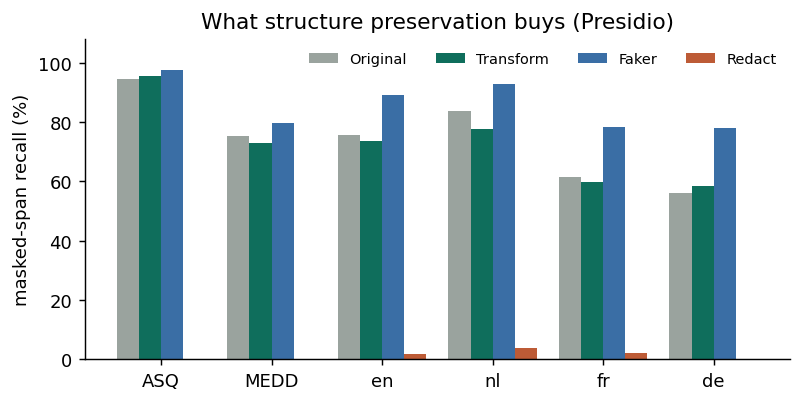

In [2]:
# grouped bars: Original / Transform / Faker / Redact (Presidio masked-span recall)
import numpy as np, matplotlib.pyplot as plt
ben=['ASQ','MEDD','en','nl','fr','de']
orig=[94.5,75.4,75.6,83.6,61.4,56.1]; tr=[95.7,72.9,73.5,77.7,59.9,58.3]
fak=[97.7,79.7,89.2,93.0,78.5,78.1]; red=[0,0,1.9,3.8,2.2,0]
x=np.arange(6); w=0.2; fig,ax=plt.subplots(figsize=(7,3.2))
ax.bar(x-1.5*w,orig,w,label='Original',color='#9aa39e')
ax.bar(x-0.5*w,tr,w,label='Transform',color='#0F6E5C')
ax.bar(x+0.5*w,fak,w,label='Faker',color='#3A6EA5')
ax.bar(x+1.5*w,red,w,label='Redact',color='#BD5B36')
ax.set_xticks(x); ax.set_xticklabels(ben); ax.set_ylabel('masked-span recall (%)')
ax.legend(ncol=4,fontsize=8,frameon=False); ax.set_ylim(0,108); plt.show()

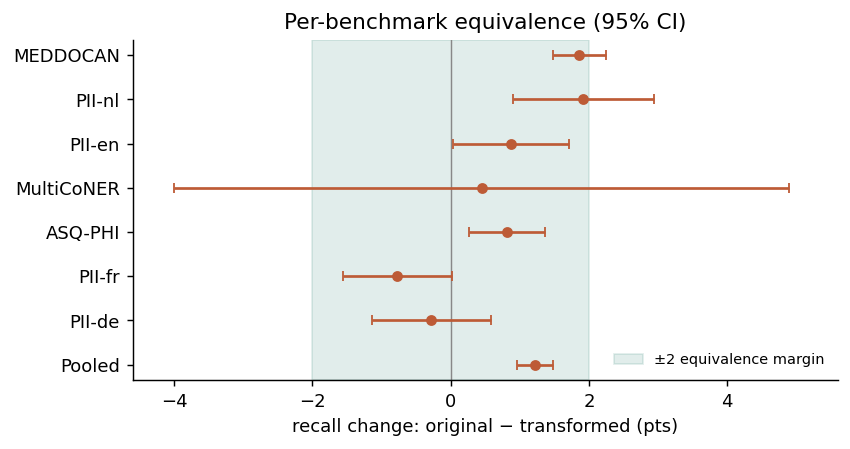

In [3]:
# forest plot: per-benchmark recall change (orig - transformed) with 95% CI and +-2 band
labels=['Pooled','PII-de','PII-fr','ASQ-PHI','MultiCoNER','PII-en','PII-nl','MEDDOCAN']
diff=[1.22,-0.28,-0.77,0.81,0.45,0.87,1.92,1.86]; err=[0.26,0.86,0.79,0.55,4.45,0.84,1.02,0.38]
y=np.arange(len(labels)); fig,ax=plt.subplots(figsize=(7,3.4))
ax.axvspan(-2,2,color='#0F6E5C',alpha=0.12,label='±2 equivalence margin')
ax.axvline(0,color='#888',lw=0.8)
ax.errorbar(diff,y,xerr=err,fmt='o',color='#BD5B36',capsize=3,ms=5)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.set_xlabel('recall change: original − transformed (pts)')
ax.legend(fontsize=8,frameon=False,loc='lower right'); plt.show()

## 7. Where to go next
- **Full evaluation** (11 detectors × 7 benchmarks × 7 languages), data subsets, and all scoring scripts: **https://custodianai.pages.dev/code**
- **Paper (PDF):** https://custodianai.pages.dev/paper.pdf
- **Interactive dashboard:** https://custodianai.pages.dev

The residual ~1.2-pt gap in the full study traces to surrogate-generation quality (truncation, salience loss, `x`-masking), not to detectors getting worse at PHI — a fixable, transform-side property.